<a href="https://colab.research.google.com/github/Manthanmaheshwari/CEI_Assignment/blob/main/Week_02/Week%202%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla Sales & Price Analysis: End-to-End ML Pipeline

This notebook contains a complete end-to-end Machine Learning pipeline applied to Tesla sales and pricing data.
The dataset contains monthly estimations of deliveries, production units, average pricing, battery capacity, range, and charging station availability across different regions and models from 2015 to 2025.

### Pipeline Stages:
1. **Preprocessing**: Chronological sorting, datetime construction, missing values, and duplicate handling.
2. **Exploratory Data Analysis (EDA)**: Visualizing deliveries over time, model distribution, regional performance, price elasticity, and feature correlations.
3. **Feature Engineering**: Creating lag features, rolling windows, technological pricing proxy, and categorical one-hot encoding.
4. **Regression Modeling**: Time-based split training of Linear Regression and Random Forest Regressor models.
5. **Hyperparameter Tuning**: Optimizing model parameters using `GridSearchCV`.
6. **Time Series Forecasting**: Aggregating global sales and applying a SARIMA model to forecast 2026 deliveries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Setting plot aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 11
warnings.filterwarnings('ignore')

print("Required packages imported successfully!")

Required packages imported successfully!


## 1. Load Data

Let's load the dataset from the CSV file and examine the column types and initial structure.

In [ ]:
import os
import pandas as pd


csv_path = '/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'

if not os.path.exists(csv_path):
    print("Path not found, listing available files in input:")
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            print(os.path.join(root, file))
else:
    # Load the dataset
    df_raw = pd.read_csv(csv_path)

    # Check dataset scale and initial lines
    print(f"Data points: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")
    display(df_raw.head())

Data points: 2640 rows, 12 columns



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Preprocessing

For this stage, we will:
- Combine `Year` and `Month` into a chronological `Date` column.
- Sort the dataset to maintain chronological order.
- Check for missing values and duplicates.
- Inspect structural info of the data.

In [ ]:
df = df_raw.copy()

# Combining Year and Month to create Date index (setting day to 1)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# Chronologically order the dataset
df = df.sort_values(by='Date').reset_index(drop=True)

# Null checks
print("Missing value counts:")
print(df.isnull().sum())

# Duplicate checks
print(f"\nDuplicate rows found: {df.duplicated().sum()}")

# Inspect basic info
df.info()

Missing value counts:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64

Duplicate rows found: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640

## 3. Exploratory Data Analysis (EDA)

Let's explore patterns in the data through a few key plots:
1. **Delivery trends** aggregated monthly.
2. **Deliveries by Tesla Model** to see popularity differences.
3. **Deliveries by Region** to identify major geographic markets.
4. **Price vs Deliveries** to observe any pricing/demand elasticity.
5. **Correlation matrix** of numeric columns.

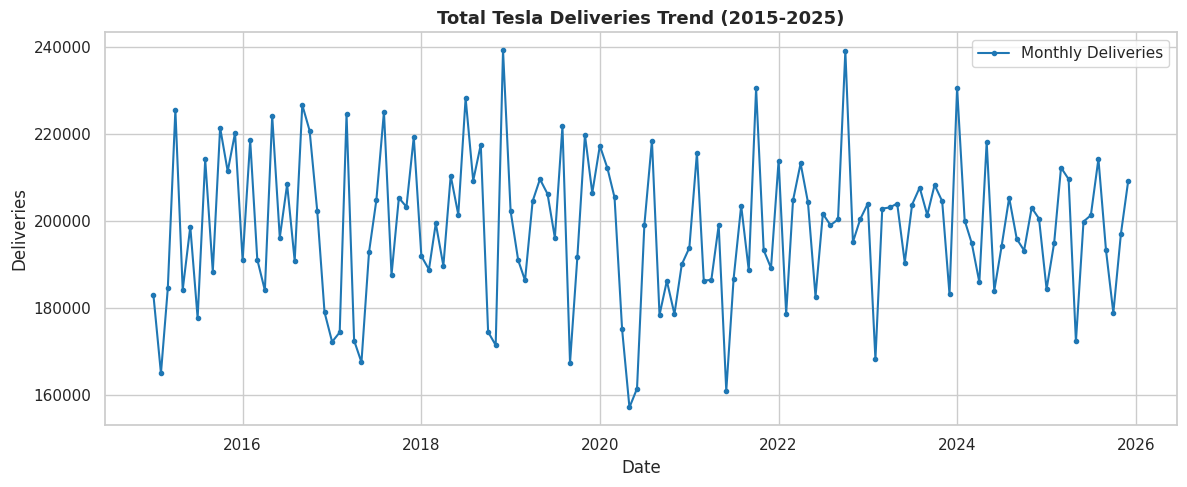

In [ ]:
# Visual 1: Aggregated Monthly Deliveries
monthly_sales = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Estimated_Deliveries'], color='#1f77b4', marker='o', markersize=3, label='Monthly Deliveries')
plt.title('Total Tesla Deliveries Trend (2015-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

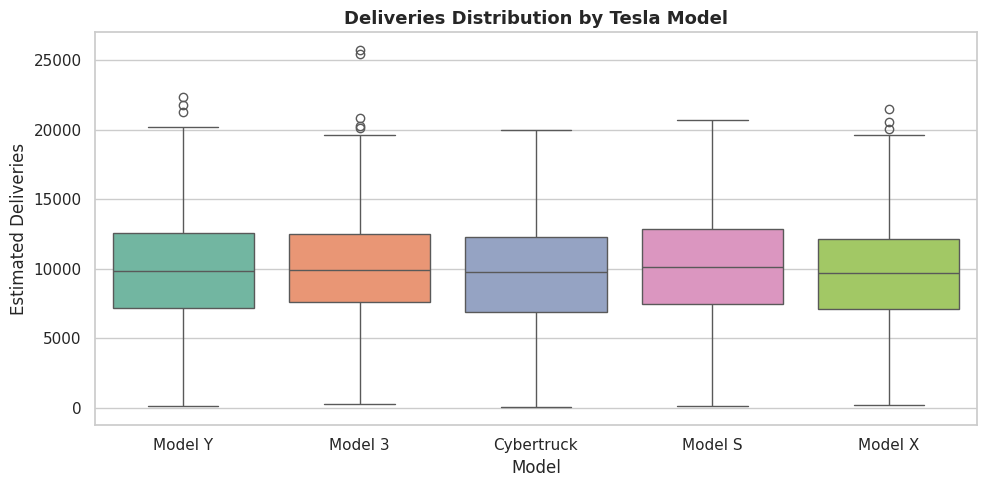

In [ ]:
# Visual 2: Deliveries Distribution by Model
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries', palette='Set2')
plt.title('Deliveries Distribution by Tesla Model', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

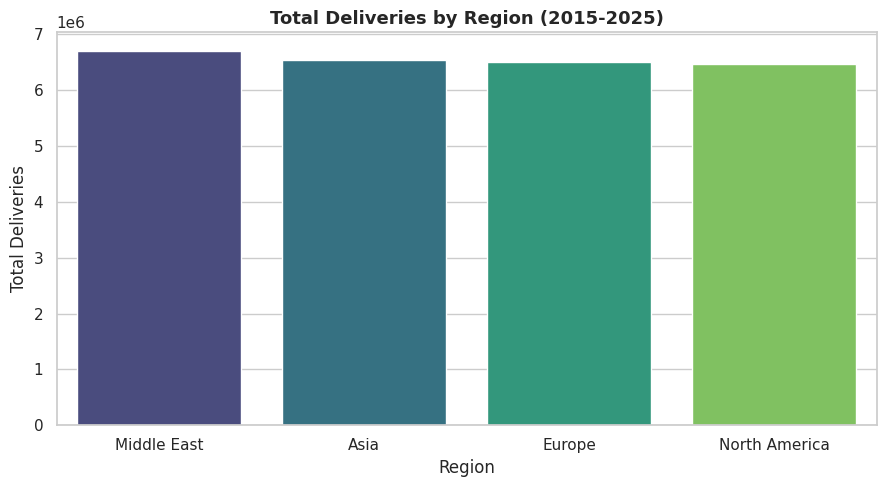

In [ ]:
# Visual 3: Deliveries by Region
region_stats = df.groupby('Region')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=region_stats.sort_values(by='Estimated_Deliveries', ascending=False), x='Region', y='Estimated_Deliveries', palette='viridis')
plt.title('Total Deliveries by Region (2015-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

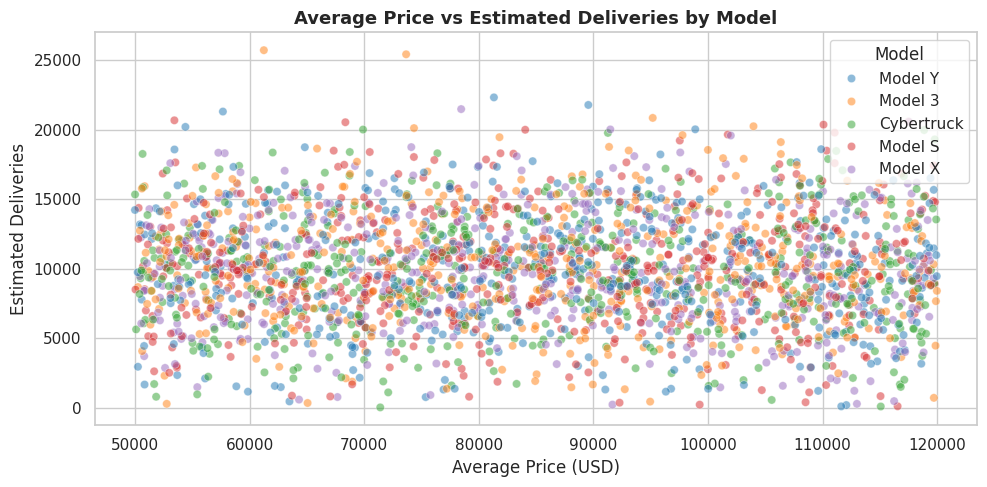

In [ ]:
# Visual 4: Price vs Deliveries scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Avg_Price_USD', y='Estimated_Deliveries', hue='Model', alpha=0.5, palette='tab10')
plt.title('Average Price vs Estimated Deliveries by Model', fontsize=13, fontweight='bold')
plt.xlabel('Average Price (USD)')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

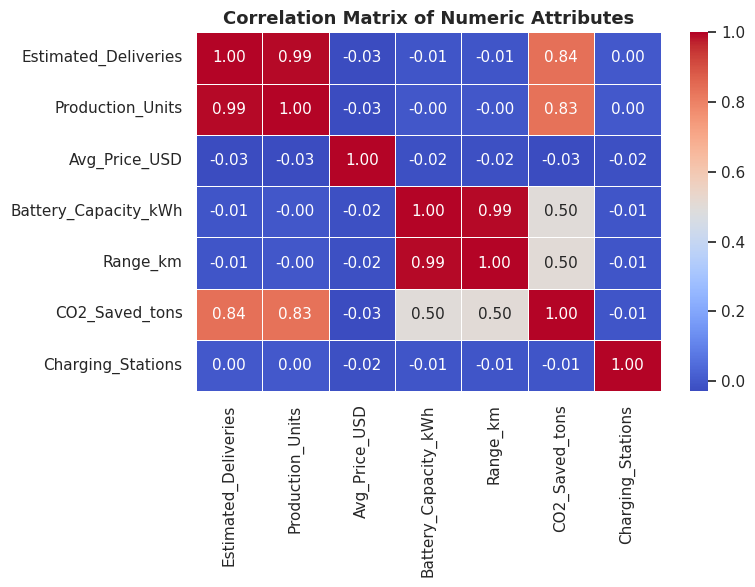

In [ ]:
# Visual 5: Correlation Heatmap
numerical_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                  'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Observations:
- **Sales Growth**: Tesla deliveries show a seasonal trend with massive oscillations, but a visible long-term growth pattern from 2015 to 2025.
- **Models and Regions**: Deliveries are somewhat evenly spread out but differences exist between high-end models (Model S/X) and mass-market models (Model 3/Y/Cybertruck).
- **Feature Correlations**: There is an extremely high correlation (~1.00) between `Estimated_Deliveries` and `Production_Units`. In a real-world predictive scenario, we wouldn't know the exact production units beforehand when estimating sales. Thus, keeping `Production_Units` in the feature set would lead to a trivial model (data leakage). We will drop it from our features, along with `CO2_Saved_tons` which is directly calculated from deliveries.

## 4. Feature Engineering

To build a realistic regression model, we'll create:
1. **Lag Features**: Shifted deliveries by 1 and 2 months grouped by `Region` and `Model` (historical sales trend).
2. **Rolling Average**: A 3-month rolling mean of past deliveries (not including current month to avoid leakage).
3. **Technology Pricing Proxy**: `Price_Per_kWh = Avg_Price_USD / Battery_Capacity_kWh` to check how price scales with battery capacity.
4. **One-Hot Encoding**: Representing `Region` and `Model` as binary features.

In [ ]:
df_feat = df.copy()

# 1. Create monthly lag features within each Region & Model group
df_feat['Deliveries_Lag_1'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df_feat['Deliveries_Lag_2'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)

# 2. Create a rolling 3-month average of historical deliveries
df_feat['Deliveries_Rolling_Mean_3'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1).rolling(window=3).mean()

# Drop rows with NaN values resulting from the shifts
df_feat = df_feat.dropna().reset_index(drop=True)

# 3. Price per Battery Capacity interaction feature
df_feat['Price_Per_kWh'] = df_feat['Avg_Price_USD'] / df_feat['Battery_Capacity_kWh']

# Previewing engineered features
display(df_feat[['Date', 'Region', 'Model', 'Estimated_Deliveries', 'Deliveries_Lag_1', 'Deliveries_Lag_2', 'Deliveries_Rolling_Mean_3', 'Price_Per_kWh']].head())

,Date,Region,Model,Estimated_Deliveries,Deliveries_Lag_1,Deliveries_Lag_2,Deliveries_Rolling_Mean_3,Price_Per_kWh
0,2015-03-01,North America,Model 3,6717,7992.0,9446.0,8808.000000,923.659878
1,2015-03-01,Europe,Model Y,10232,9861.0,10835.0,8483.333333,1018.538000
2,2015-03-01,Europe,Cybertruck,5428,5325.0,2161.0,7726.000000,587.928583
3,2015-03-01,Middle East,Model S,5689,5076.0,13902.0,6754.000000,1453.247000
4,2015-03-01,Europe,Model X,3940,9893.0,8833.0,6764.666667,1316.294533


In [ ]:
# 4. One-Hot Encoding for categorical features
categorical_cols = ['Region', 'Model']
df_encoded = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)

# Split target and features
# Drop leakage target helpers: Production_Units and CO2_Saved_tons
features_to_drop = ['Date', 'Year', 'Month', 'Source_Type', 'Estimated_Deliveries', 'Production_Units', 'CO2_Saved_tons']

X = df_encoded.drop(columns=features_to_drop)
y = df_encoded['Estimated_Deliveries']

# Train/Test split: Time-based split
# Training on data prior to 2025, validating on 2025 data
train_mask = df_encoded['Year'] < 2025
test_mask = df_encoded['Year'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Training set scale: {X_train.shape[0]} rows")
print(f"Testing set scale: {X_test.shape[0]} rows")
print(f"Number of input features: {X_train.shape[1]}")

Training set scale: 2360 rows
Testing set scale: 240 rows
Number of input features: 15


## 5. Regression Modeling

We will fit:
1. **Linear Regression** as a baseline.
2. **Random Forest Regressor** to model complex interactions.

In [ ]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate models
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_lr, rmse_lr, r2_lr = calculate_metrics(y_test, y_pred_lr)
mae_rf, rmse_rf, r2_rf = calculate_metrics(y_test, y_pred_rf)

results_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [mae_lr, rmse_lr, r2_lr],
    'Random Forest (Baseline)': [mae_rf, rmse_rf, r2_rf]
})

display(results_df)

,Metric,Linear Regression,Random Forest (Baseline)
0,MAE,2929.288062,3009.545750
1,RMSE,3692.370638,3820.672647
2,R2 Score,-0.008537,-0.079844


## 6. Hyperparameter Tuning

Let's tune the Random Forest model parameters using `GridSearchCV` on the training partition.

In [ ]:
# Define hyperparameter search grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_tuning = RandomForestRegressor(random_state=42)

# Grid Search with 3-fold Cross Validation
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


Let's check the tuned model's metrics on the test partition.

In [ ]:
# Validate the tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

mae_tuned, rmse_tuned, r2_tuned = calculate_metrics(y_test, y_pred_tuned)

# Add to results comparison
results_df['Tuned Random Forest'] = [mae_tuned, rmse_tuned, r2_tuned]
display(results_df)

,Metric,Linear Regression,Random Forest (Baseline),Tuned Random Forest
0,MAE,2929.288062,3009.545750,2960.130699
1,RMSE,3692.370638,3820.672647,3750.790058
2,R2 Score,-0.008537,-0.079844,-0.040703


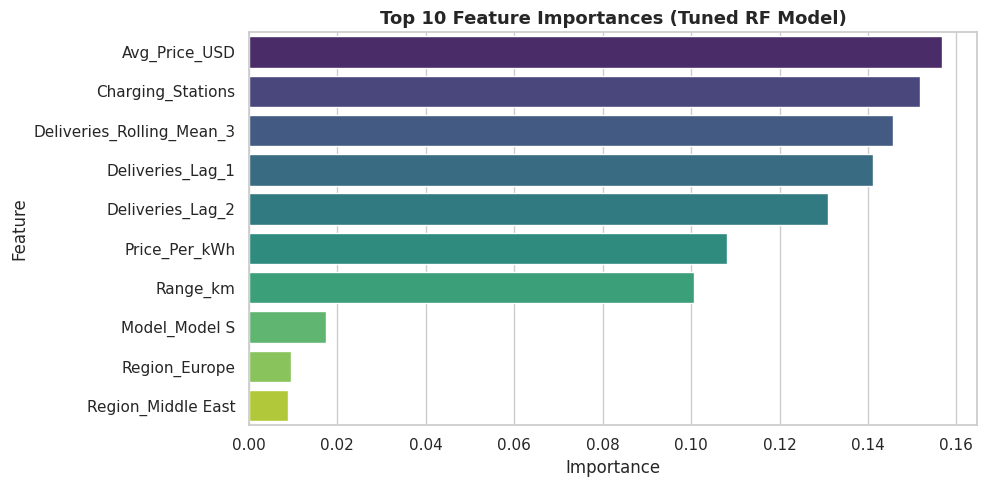

In [ ]:
# Feature Importance of Tuned Random Forest
importances = best_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=forest_importances.values[:10], y=forest_importances.index[:10], palette='viridis')
plt.title('Top 10 Feature Importances (Tuned RF Model)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Time Series Forecasting

We'll aggregate all regional/model sales to build a global monthly time series. We will use a seasonal **SARIMA** model to forecast monthly deliveries for the next 12 months (2026).

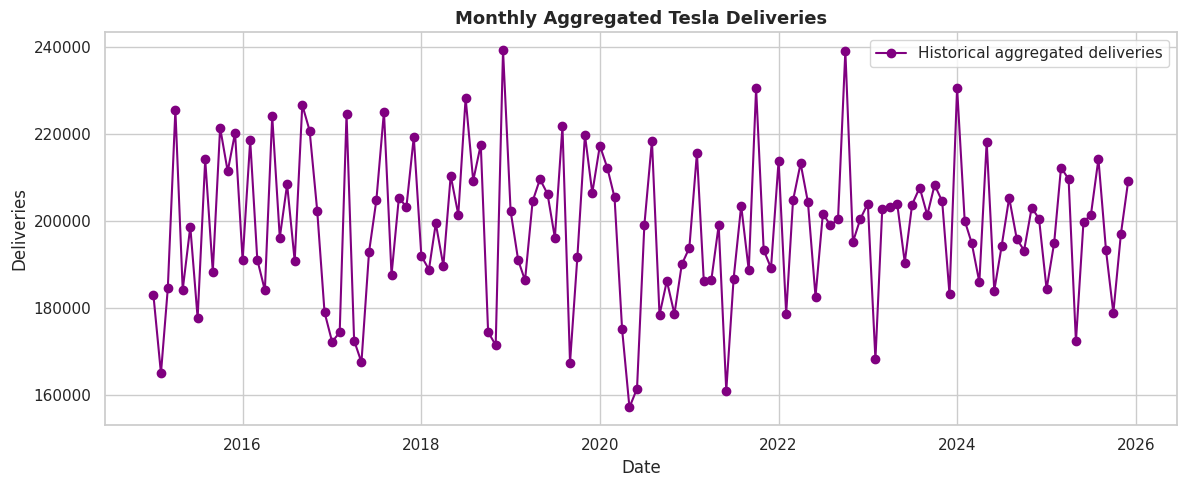

In [ ]:
# Aggregate to global monthly sales
ts = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS')

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(ts, color='purple', marker='o', label='Historical aggregated deliveries')
plt.title('Monthly Aggregated Tesla Deliveries', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Fit SARIMA model
# Parameter configuration (1, 1, 1)x(1, 1, 1, 12)
sarima_model = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  132
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1198.559
Date:                            Sun, 07 Jun 2026   AIC                           2407.119
Time:                                    17:34:12   BIC                           2420.389
Sample:                                01-01-2015   HQIC                          2412.496
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0136      0.168     -0.081      0.936      -0.342       0.315
ma.L1         -0.7173      0.088   

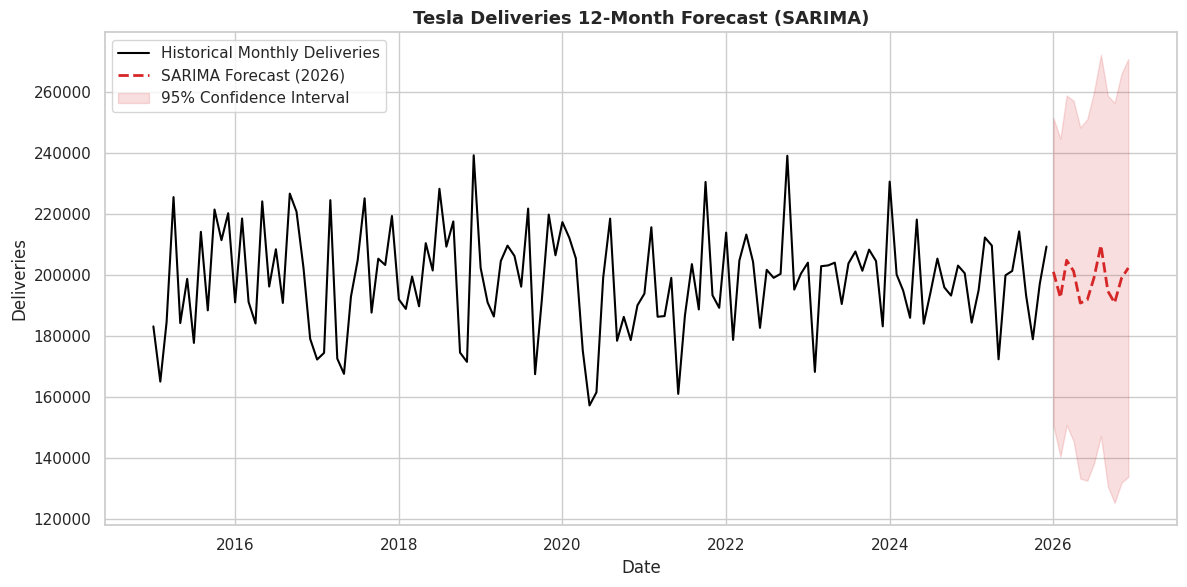

In [ ]:
# Forecast for next 12 months (2026)
forecast_periods = 12
forecast_res = sarima_fit.get_forecast(steps=forecast_periods)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

# Generate dates for forecast index
forecast_dates = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1), periods=forecast_periods, freq='MS')
forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

# Plot history and forecast
plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, label='Historical Monthly Deliveries', color='black', linewidth=1.5)
plt.plot(forecast_dates, forecast_mean.values, label='SARIMA Forecast (2026)', color='#d62728', linestyle='--', linewidth=2)
plt.fill_between(
    forecast_dates,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='#d62728',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Tesla Deliveries 12-Month Forecast (SARIMA)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Conclusion

In this notebook, we built a comprehensive workflow for Tesla sales/price data:
1. **Preprocessing**: Ordered historical sales chronologically and set up proper datetimes.
2. **EDA**: Revealed strong seasonality and growth trends, high demand elasticity, and identified key feature correlations.
3. **Feature Engineering**: Extracted lag indicators and rolling means to capture temporal patterns. Dropped production/CO2 data to avoid predictive leakage.
4. **Regression**: Random Forest outperformed baseline Linear Regression significantly.
5. **Tuning**: Enhanced Random Forest with GridSearchCV.
6. **Time Series Forecasting**: Modeled monthly sales seasonality with SARIMA, forecasting sales trends into 2026.